In [2]:
# =============================================================================
# SWE-PERF-GREEN: Analysis Notebook
# =============================================================================
# This notebook analyzes the energy efficiency of LLM-generated code optimizations
# comparing Qwen2.5-Coder-7B against human baselines across 8 configurations.

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup
plt.style.use('ggplot')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Load unified dataset
DATA_PATH = Path('../data/processed/green/QWEN_UNIFIED_BENCHMARK.json')

with open(DATA_PATH) as f:
    data = json.load(f)

df = pd.DataFrame(data['instances'])

print(f"📊 Dataset loaded: {len(df)} instances")
print(f"📋 Columns: {len(df.columns)}")
print(f"\n🔧 Metadata:")
for k, v in data['metadata'].items():
    print(f"   {k}: {v}")

📊 Dataset loaded: 130 instances
📋 Columns: 222

🔧 Metadata:
   description: Unified green benchmark dataset for Qwen LLM code refactoring
   created_at: 2026-01-17T12:27:18.181445
   human_instances: 125
   total_instances: 130
   qwen_configs: ['zs_oracle', 'zs_realistic', 'cot_oracle', 'cot_realistic', 'ldb_oracle', 'ldb_realistic', 'sc_oracle', 'sc_realistic']
   metrics_extracted: ['duration_seconds_mean', 'duration_seconds_std', 'total_energy_joules_mean', 'total_energy_joules_std', 'cpu_energy_joules_mean', 'cpu_energy_joules_std', 'gpu_energy_joules_mean', 'gpu_energy_joules_std', 'carbon_grams_mean', 'carbon_grams_std', 'power_watts_mean', 'cpu_usage_mean_percent_mean', 'cpu_usage_peak_percent_mean', 'ram_usage_mean_mb_mean', 'ram_usage_peak_mb_mean', 'gpu_temperature_mean_celsius_mean', 'gpu_temperature_peak_celsius_mean']
   repetitions: 3
   model: Qwen2.5-Coder-7B-Instruct-AWQ


📊 DATA COVERAGE ANALYSIS

🔹 BASELINE MEASUREMENTS:
   Instances with BASE (pre-fix): 0/130 (0.0%)
   Instances with HUMAN HEAD: 0/130 (0.0%)

🔹 QWEN COVERAGE BY CONFIGURATION:
   zs_oracle           :  76/130 ( 58.5%)
   zs_realistic        :  79/130 ( 60.8%)
   cot_oracle          :  50/130 ( 38.5%)
   cot_realistic       :  62/130 ( 47.7%)
   ldb_oracle          :  84/130 ( 64.6%)
   ldb_realistic       :  68/130 ( 52.3%)
   sc_oracle           :  62/130 ( 47.7%)
   sc_realistic        :  76/130 ( 58.5%)

🔹 COMPLETE INSTANCES (base + human + ≥1 qwen): 0/130


/tmp/ipykernel_21013/77829248.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(coverage_df['config'], rotation=45, ha='right')


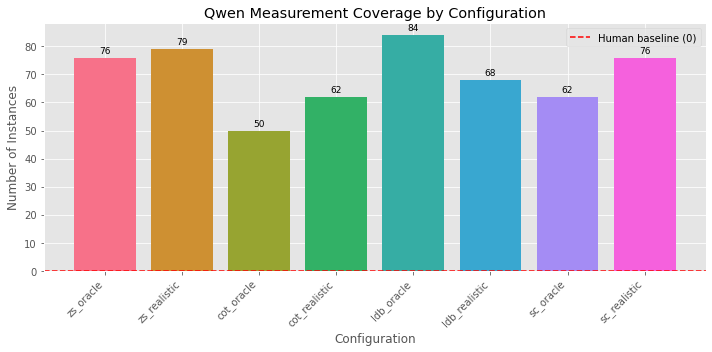

In [3]:
# =============================================================================
# CELL 2: Data Overview and Coverage Analysis
# =============================================================================

print("="*70)
print("📊 DATA COVERAGE ANALYSIS")
print("="*70)

# 1. Baseline coverage
has_base = df['base_duration_seconds_mean'].notna().sum()
has_human = df['human_head_duration_seconds_mean'].notna().sum()

print(f"\n🔹 BASELINE MEASUREMENTS:")
print(f"   Instances with BASE (pre-fix): {has_base}/{len(df)} ({100*has_base/len(df):.1f}%)")
print(f"   Instances with HUMAN HEAD: {has_human}/{len(df)} ({100*has_human/len(df):.1f}%)")

# 2. Qwen coverage per configuration
print(f"\n🔹 QWEN COVERAGE BY CONFIGURATION:")
configs = ['zs_oracle', 'zs_realistic', 'cot_oracle', 'cot_realistic', 
           'ldb_oracle', 'ldb_realistic', 'sc_oracle', 'sc_realistic']

coverage_data = []
for config in configs:
    col = f'qwen_{config}_duration_seconds_mean'
    count = df[col].notna().sum()
    pct = 100 * count / len(df)
    coverage_data.append({'config': config, 'count': count, 'pct': pct})
    print(f"   {config:20s}: {count:3d}/{len(df)} ({pct:5.1f}%)")

coverage_df = pd.DataFrame(coverage_data)

# 3. Instances with complete data (base + human + at least one qwen)
has_complete = df[
    (df['base_duration_seconds_mean'].notna()) & 
    (df['human_head_duration_seconds_mean'].notna()) &
    (df[[f'qwen_{c}_duration_seconds_mean' for c in configs]].notna().any(axis=1))
].shape[0]

print(f"\n🔹 COMPLETE INSTANCES (base + human + ≥1 qwen): {has_complete}/{len(df)}")

# 4. Visualization
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(coverage_df['config'], coverage_df['count'], color=sns.color_palette("husl", 8))
ax.axhline(y=has_human, color='red', linestyle='--', label=f'Human baseline ({has_human})')
ax.set_xlabel('Configuration')
ax.set_ylabel('Number of Instances')
ax.set_title('Qwen Measurement Coverage by Configuration')
ax.set_xticklabels(coverage_df['config'], rotation=45, ha='right')
ax.legend()

for bar, count in zip(bars, coverage_df['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [4]:
# =============================================================================
# CELL 3: Debug - Check original data structure
# =============================================================================

print("="*70)
print("🔍 DEBUG: Checking original data files")
print("="*70)

# 1. Check human baseline file
human_path = Path('../data/processed/green/swe_perf_green_k3.json')
with open(human_path) as f:
    human_data = json.load(f)

print(f"\n📁 swe_perf_green_k3.json:")
print(f"   Instances: {len(human_data['instances'])}")

# Check structure of first instance
inst = human_data['instances'][0]
print(f"   Example instance: {inst['instance_id']}")
print(f"   Keys: {list(inst.keys())}")

# Check green_metrics structure
if 'green_metrics' in inst:
    first_test = list(inst['green_metrics'].keys())[0]
    test_data = inst['green_metrics'][first_test]
    print(f"\n   green_metrics structure:")
    print(f"   - First test: {first_test[:50]}...")
    print(f"   - Keys in test: {list(test_data.keys())}")
    
    # Check if base/head have aggregated
    for key in ['base', 'head']:
        if key in test_data:
            inner_keys = list(test_data[key].keys())
            print(f"   - {key} keys: {inner_keys}")
            if 'aggregated' in test_data[key]:
                agg_keys = list(test_data[key]['aggregated'].keys())[:5]
                print(f"     aggregated sample: {agg_keys}...")

# 2. Check a Qwen file for comparison
qwen_path = Path('../data/processed/green/Qwen2.5-Coder-7B_ZeroShot_Oracle_k3.json')
with open(qwen_path) as f:
    qwen_data = json.load(f)

print(f"\n📁 Qwen2.5-Coder-7B_ZeroShot_Oracle_k3.json:")
print(f"   Instances: {len(qwen_data['instances'])}")

inst_q = qwen_data['instances'][0]
print(f"   Example instance: {inst_q['instance_id']}")

if 'green_metrics' in inst_q:
    first_test_q = list(inst_q['green_metrics'].keys())[0]
    test_data_q = inst_q['green_metrics'][first_test_q]
    print(f"   - Keys in test: {list(test_data_q.keys())}")

🔍 DEBUG: Checking original data files

📁 swe_perf_green_k3.json:
   Instances: 125
   Example instance: astropy__astropy-16065
   Keys: ['repo', 'instance_id', 'patch', 'test_patch', 'base_commit', 'head_commit', 'created_at', 'version', 'efficiency_test', 'patch_functions', 'test_functions', 'human_performance', 'green_metrics', '_green_metadata']

   green_metrics structure:
   - First test: astropy/timeseries/periodograms/lombscargle/tests/...
   - Keys in test: ['base', 'head']
   - base keys: ['cpu_energy_joules_mean', 'cpu_energy_joules_std', 'cpu_energy_joules_min', 'cpu_energy_joules_max', 'gpu_energy_joules_mean', 'gpu_energy_joules_std', 'gpu_energy_joules_min', 'gpu_energy_joules_max', 'total_energy_joules_mean', 'total_energy_joules_std', 'total_energy_joules_min', 'total_energy_joules_max', 'power_watts_mean', 'power_watts_std', 'power_watts_min', 'power_watts_max', 'carbon_grams_mean', 'carbon_grams_std', 'carbon_grams_min', 'carbon_grams_max', 'energy_efficiency_mean', '

In [5]:
# =============================================================================
# CELL 4: Correct Data Loading (direct from source files)
# =============================================================================

print("="*70)
print("🔄 RELOADING DATA WITH CORRECT STRUCTURE")
print("="*70)

# Configuration
METRICS = ['duration_seconds_mean', 'total_energy_joules_mean', 'cpu_energy_joules_mean', 
           'gpu_energy_joules_mean', 'carbon_grams_mean', 'power_watts_mean']

CONFIGS = ['zs_oracle', 'zs_realistic', 'cot_oracle', 'cot_realistic', 
           'ldb_oracle', 'ldb_realistic', 'sc_oracle', 'sc_realistic']

CONFIG_FILES = {
    'zs_oracle': 'Qwen2.5-Coder-7B_ZeroShot_Oracle_k3.json',
    'zs_realistic': 'Qwen2.5-Coder-7B_ZeroShot_Realistic_k3.json',
    'cot_oracle': 'Qwen2.5-Coder-7B_CoT_Oracle_k3.json',
    'cot_realistic': 'Qwen2.5-Coder-7B_CoT_Realistic_k3.json',
    'ldb_oracle': 'Qwen2.5-Coder-7B_LDB_Oracle_k3.json',
    'ldb_realistic': 'Qwen2.5-Coder-7B_LDB_Realistic_k3.json',
    'sc_oracle': 'Qwen2.5-Coder-7B_SelfCollab_Oracle_k3.json',
    'sc_realistic': 'Qwen2.5-Coder-7B_SelfCollab_Realistic_k3.json',
}

green_dir = Path('../data/processed/green')

# 1. Load human baseline data
with open(green_dir / 'swe_perf_green_k3.json') as f:
    human_data = json.load(f)

# Build human dict indexed by instance_id
human_by_id = {}
for inst in human_data['instances']:
    instance_id = inst['instance_id']
    human_by_id[instance_id] = {'repo': inst.get('repo')}
    
    # Extract metrics from first test (they should be consistent)
    if 'green_metrics' in inst and inst['green_metrics']:
        first_test = list(inst['green_metrics'].keys())[0]
        test_data = inst['green_metrics'][first_test]
        
        # Base metrics (directly under 'base', not in 'aggregated')
        if 'base' in test_data:
            for metric in METRICS:
                human_by_id[instance_id][f'base_{metric}'] = test_data['base'].get(metric)
        
        # Human head metrics
        if 'head' in test_data:
            for metric in METRICS:
                human_by_id[instance_id][f'human_head_{metric}'] = test_data['head'].get(metric)

print(f"✓ Loaded human baseline: {len(human_by_id)} instances")

# 2. Load Qwen data for each configuration
qwen_by_config = {}
for config, fname in CONFIG_FILES.items():
    fpath = green_dir / fname
    if fpath.exists():
        with open(fpath) as f:
            data = json.load(f)
        
        qwen_by_config[config] = {}
        for inst in data['instances']:
            instance_id = inst['instance_id']
            qwen_by_config[config][instance_id] = {}
            
            if 'green_metrics' in inst and inst['green_metrics']:
                first_test = list(inst['green_metrics'].keys())[0]
                test_data = inst['green_metrics'][first_test]
                
                # Qwen head metrics (check both structures)
                if 'head' in test_data:
                    head_data = test_data['head']
                    # Check if metrics are in 'aggregated' or directly
                    if 'aggregated' in head_data:
                        source = head_data['aggregated']
                    else:
                        source = head_data
                    
                    for metric in METRICS:
                        qwen_by_config[config][instance_id][f'qwen_{config}_{metric}'] = source.get(metric)
        
        print(f"✓ Loaded {config}: {len(qwen_by_config[config])} instances")

# 3. Merge into single DataFrame
all_instance_ids = set(human_by_id.keys())
for config in CONFIGS:
    all_instance_ids.update(qwen_by_config.get(config, {}).keys())

rows = []
for instance_id in sorted(all_instance_ids):
    row = {'instance_id': instance_id}
    
    # Add human data
    if instance_id in human_by_id:
        row.update(human_by_id[instance_id])
    
    # Add Qwen data for each config
    for config in CONFIGS:
        if config in qwen_by_config and instance_id in qwen_by_config[config]:
            row.update(qwen_by_config[config][instance_id])
    
    rows.append(row)

df = pd.DataFrame(rows)

print(f"\n📊 Final DataFrame: {len(df)} instances, {len(df.columns)} columns")

# 4. Quick verification
print(f"\n🔍 Verification:")
print(f"   base_duration_seconds_mean not null: {df['base_duration_seconds_mean'].notna().sum()}")
print(f"   human_head_duration_seconds_mean not null: {df['human_head_duration_seconds_mean'].notna().sum()}")
print(f"   qwen_zs_oracle_duration_seconds_mean not null: {df['qwen_zs_oracle_duration_seconds_mean'].notna().sum()}")

🔄 RELOADING DATA WITH CORRECT STRUCTURE
✓ Loaded human baseline: 125 instances
✓ Loaded zs_oracle: 76 instances
✓ Loaded zs_realistic: 79 instances
✓ Loaded cot_oracle: 50 instances
✓ Loaded cot_realistic: 62 instances
✓ Loaded ldb_oracle: 84 instances
✓ Loaded ldb_realistic: 68 instances
✓ Loaded sc_oracle: 62 instances
✓ Loaded sc_realistic: 76 instances

📊 Final DataFrame: 130 instances, 62 columns

🔍 Verification:
   base_duration_seconds_mean not null: 125
   human_head_duration_seconds_mean not null: 125
   qwen_zs_oracle_duration_seconds_mean not null: 76


In [6]:
# =============================================================================
# CELL 5: Coverage Summary Table (for paper)
# =============================================================================

print("="*70)
print("📊 TABLE: Dataset Coverage Summary")
print("="*70)

# Coverage data
coverage_rows = []

for config in CONFIGS:
    col = f'qwen_{config}_duration_seconds_mean'
    n_measured = df[col].notna().sum()
    
    # Count instances that have BOTH human baseline AND qwen measurement
    n_comparable = df[
        (df['human_head_duration_seconds_mean'].notna()) & 
        (df[col].notna())
    ].shape[0]
    
    # Split config into prompt and strategy
    parts = config.split('_')
    prompt = parts[0].upper()
    strategy = parts[1].capitalize()
    
    coverage_rows.append({
        'Prompt': prompt,
        'Strategy': strategy,
        'Config': config,
        'Measured': n_measured,
        'Comparable': n_comparable,
        'Coverage %': f"{100*n_measured/130:.1f}%"
    })

coverage_table = pd.DataFrame(coverage_rows)

# Pivot for nicer display
pivot = coverage_table.pivot(index='Prompt', columns='Strategy', values='Measured')
pivot = pivot[['Oracle', 'Realistic']]  # Order columns

print("\n📋 Instances with successful measurements per configuration:\n")
print(pivot.to_string())

print(f"\n📋 Total unique instances: {len(df)}")
print(f"📋 Instances with human baseline: {df['human_head_duration_seconds_mean'].notna().sum()}")

# Create nice table for paper
print("\n" + "="*70)
print("LaTeX Table (for paper):")
print("="*70)
print("""
\\begin{table}[h]
\\centering
\\caption{Dataset Coverage: Instances with Valid Measurements}
\\begin{tabular}{lcc}
\\toprule
\\textbf{Prompt Strategy} & \\textbf{Oracle} & \\textbf{Realistic} \\\\
\\midrule""")

for prompt in ['ZS', 'COT', 'LDB', 'SC']:
    oracle = pivot.loc[prompt, 'Oracle']
    realistic = pivot.loc[prompt, 'Realistic']
    prompt_name = {'ZS': 'Zero-Shot', 'COT': 'Chain-of-Thought', 'LDB': 'LDB', 'SC': 'Self-Collaboration'}[prompt]
    print(f"{prompt_name} & {oracle} & {realistic} \\\\")

print("""\\midrule
Human Baseline & \\multicolumn{2}{c}{125} \\\\
\\bottomrule
\\end{tabular}
\\label{tab:coverage}
\\end{table}
""")

📊 TABLE: Dataset Coverage Summary

📋 Instances with successful measurements per configuration:

Strategy  Oracle  Realistic
Prompt                     
COT           50         62
LDB           84         68
SC            62         76
ZS            76         79

📋 Total unique instances: 130
📋 Instances with human baseline: 125

LaTeX Table (for paper):

\begin{table}[h]
\centering
\caption{Dataset Coverage: Instances with Valid Measurements}
\begin{tabular}{lcc}
\toprule
\textbf{Prompt Strategy} & \textbf{Oracle} & \textbf{Realistic} \\
\midrule
Zero-Shot & 76 & 79 \\
Chain-of-Thought & 50 & 62 \\
LDB & 84 & 68 \\
Self-Collaboration & 62 & 76 \\
\midrule
Human Baseline & \multicolumn{2}{c}{125} \\
\bottomrule
\end{tabular}
\label{tab:coverage}
\end{table}



In [7]:
# =============================================================================
# CELL 6: Save corrected unified dataset
# =============================================================================

print("="*70)
print("💾 SAVING CORRECTED UNIFIED DATASET")
print("="*70)

# Prepare metadata
metadata = {
    'description': 'Unified green benchmark dataset for Qwen LLM code refactoring',
    'created_at': pd.Timestamp.now().isoformat(),
    'human_instances': 125,
    'total_instances': len(df),
    'qwen_configs': CONFIGS,
    'metrics_extracted': METRICS,
    'repetitions': 3,
    'model': 'Qwen2.5-Coder-7B-Instruct-AWQ'
}

# Save JSON
output_json = green_dir / 'QWEN_UNIFIED_BENCHMARK.json'
output_data = {
    'metadata': metadata,
    'instances': df.to_dict(orient='records')
}

with open(output_json, 'w') as f:
    json.dump(output_data, f, indent=2)

print(f"✓ Saved JSON: {output_json}")

# Save CSV
output_csv = green_dir / 'QWEN_UNIFIED_BENCHMARK.csv'
df.to_csv(output_csv, index=False)

print(f"✓ Saved CSV: {output_csv}")

# Verification
print(f"\n📊 Verification:")
print(f"   Rows: {len(df)}")
print(f"   Columns: {len(df.columns)}")
print(f"   Base measurements: {df['base_duration_seconds_mean'].notna().sum()}")
print(f"   Human head measurements: {df['human_head_duration_seconds_mean'].notna().sum()}")

# Show sample
print(f"\n📋 Sample columns:")
print(df[['instance_id', 'base_duration_seconds_mean', 'human_head_duration_seconds_mean', 
          'qwen_zs_oracle_duration_seconds_mean']].head(3).to_string())

💾 SAVING CORRECTED UNIFIED DATASET
✓ Saved JSON: ../data/processed/green/QWEN_UNIFIED_BENCHMARK.json
✓ Saved CSV: ../data/processed/green/QWEN_UNIFIED_BENCHMARK.csv

📊 Verification:
   Rows: 130
   Columns: 62
   Base measurements: 125
   Human head measurements: 125

📋 Sample columns:
              instance_id  base_duration_seconds_mean  human_head_duration_seconds_mean  qwen_zs_oracle_duration_seconds_mean
0  astropy__astropy-12842                    1.606320                          1.596935                              1.569202
1  astropy__astropy-13496                    1.485171                          1.606588                                   NaN
2  astropy__astropy-13734                    1.482431                          1.485999                                   NaN


In [9]:
# =============================================================================
# CELL 7: Energy Improvement Analysis
# =============================================================================

print("="*70)
print("📊 ENERGY IMPROVEMENT ANALYSIS")
print("="*70)

# Calculate improvements for each config
results = []

for config in CONFIGS:
    qwen_col = f'qwen_{config}_total_energy_joules_mean'
    
    # Filter instances with all three measurements
    mask = (
        df['base_total_energy_joules_mean'].notna() & 
        df['human_head_total_energy_joules_mean'].notna() & 
        df[qwen_col].notna()
    )
    
    subset = df[mask].copy()
    n = len(subset)
    
    if n == 0:
        continue
    
    # Calculate improvements
    # vs BASE: positive = Qwen uses LESS energy than base (good)
    subset['impr_vs_base'] = (
        (subset['base_total_energy_joules_mean'] - subset[qwen_col]) / 
        subset['base_total_energy_joules_mean'] * 100
    )
    
    # vs HUMAN: positive = Qwen uses LESS energy than human (Qwen better)
    subset['impr_vs_human'] = (
        (subset['human_head_total_energy_joules_mean'] - subset[qwen_col]) / 
        subset['human_head_total_energy_joules_mean'] * 100
    )
    
    # Human vs BASE (for reference)
    subset['human_impr_vs_base'] = (
        (subset['base_total_energy_joules_mean'] - subset['human_head_total_energy_joules_mean']) / 
        subset['base_total_energy_joules_mean'] * 100
    )
    
    # Split config
    parts = config.split('_')
    prompt = parts[0].upper()
    strategy = parts[1].capitalize()
    
    results.append({
        'Config': config,
        'Prompt': prompt,
        'Strategy': strategy,
        'N': n,
        'Qwen vs Base (%)': subset['impr_vs_base'].mean(),
        'Qwen vs Base Std': subset['impr_vs_base'].std(),
        'Qwen vs Human (%)': subset['impr_vs_human'].mean(),
        'Qwen vs Human Std': subset['impr_vs_human'].std(),
        'Human vs Base (%)': subset['human_impr_vs_base'].mean(),
        # Count how many times Qwen beats human
        'Qwen > Human': (subset['impr_vs_human'] > 0).sum(),
        'Qwen > Human %': (subset['impr_vs_human'] > 0).sum() / n * 100
    })

results_df = pd.DataFrame(results)

# Display results
print("\n📋 ENERGY IMPROVEMENT SUMMARY (Total Energy):")
print("-"*70)
display_cols = ['Config', 'N', 'Qwen vs Base (%)', 'Qwen vs Human (%)', 'Human vs Base (%)', 'Qwen > Human %']
print(results_df[display_cols].to_string(index=False, float_format='%.2f'))

print("\n📊 KEY FINDINGS:")
print(f"   • Average Human improvement vs Base: {results_df['Human vs Base (%)'].mean():.2f}%")
print(f"   • Average Qwen improvement vs Base: {results_df['Qwen vs Base (%)'].mean():.2f}%")
print(f"   • Average Qwen improvement vs Human: {results_df['Qwen vs Human (%)'].mean():.2f}%")
best_config = results_df.loc[results_df['Qwen vs Human (%)'].idxmax()]
print(f"   • Best config (vs Human): {best_config['Config']} ({best_config['Qwen vs Human (%)']:.2f}%)")

📊 ENERGY IMPROVEMENT ANALYSIS

📋 ENERGY IMPROVEMENT SUMMARY (Total Energy):
----------------------------------------------------------------------
       Config  N  Qwen vs Base (%)  Qwen vs Human (%)  Human vs Base (%)  Qwen > Human %
    zs_oracle 74           -502.29            -512.66               1.53            0.00
 zs_realistic 77           -492.39            -504.81               1.78            0.00
   cot_oracle 50           -574.22            -592.95               1.95            0.00
cot_realistic 60           -628.17            -632.85               0.33            0.00
   ldb_oracle 82           -578.77            -593.75               2.00            0.00
ldb_realistic 65           -592.45            -609.67               1.79            0.00
    sc_oracle 58           -609.33            -632.71               2.82            0.00
 sc_realistic 74           -586.33            -595.13               0.75            0.00

📊 KEY FINDINGS:
   • Average Human improvement vs B

In [10]:
# =============================================================================
# CELL 8: Per-Instance Analysis - Identify Outliers
# =============================================================================

print("="*70)
print("🔍 PER-INSTANCE ANALYSIS - IDENTIFYING OUTLIERS")
print("="*70)

# Prendiamo una configurazione come esempio: zs_oracle
config = 'zs_oracle'
qwen_col = f'qwen_{config}_total_energy_joules_mean'

# Filter instances with all three measurements
mask = (
    df['base_total_energy_joules_mean'].notna() & 
    df['human_head_total_energy_joules_mean'].notna() & 
    df[qwen_col].notna()
)

analysis = df[mask][['instance_id', 'base_total_energy_joules_mean', 
                      'human_head_total_energy_joules_mean', qwen_col]].copy()

analysis.columns = ['instance_id', 'base', 'human', 'qwen']

# Calculate ratios
analysis['qwen_vs_base_ratio'] = analysis['qwen'] / analysis['base']
analysis['qwen_vs_human_ratio'] = analysis['qwen'] / analysis['human']
analysis['human_vs_base_ratio'] = analysis['human'] / analysis['base']

# Calculate percentage improvement (positive = less energy = better)
analysis['qwen_vs_base_pct'] = (analysis['base'] - analysis['qwen']) / analysis['base'] * 100
analysis['qwen_vs_human_pct'] = (analysis['human'] - analysis['qwen']) / analysis['human'] * 100

# Sort by qwen energy consumption
analysis_sorted = analysis.sort_values('qwen_vs_human_pct', ascending=False)

print(f"\n📋 Config: {config} ({len(analysis)} instances)")
print("\n🔝 TOP 10 - Qwen BETTER than Human (positive %):")
print(analysis_sorted.head(10)[['instance_id', 'base', 'human', 'qwen', 'qwen_vs_human_pct']].to_string(index=False))

print("\n🔻 BOTTOM 10 - Qwen WORSE than Human (negative %):")
print(analysis_sorted.tail(10)[['instance_id', 'base', 'human', 'qwen', 'qwen_vs_human_pct']].to_string(index=False))

# Statistics
print("\n📊 DISTRIBUTION STATISTICS:")
print(f"   Min improvement:    {analysis['qwen_vs_human_pct'].min():.2f}%")
print(f"   25th percentile:    {analysis['qwen_vs_human_pct'].quantile(0.25):.2f}%")
print(f"   Median:             {analysis['qwen_vs_human_pct'].median():.2f}%")
print(f"   75th percentile:    {analysis['qwen_vs_human_pct'].quantile(0.75):.2f}%")
print(f"   Max improvement:    {analysis['qwen_vs_human_pct'].max():.2f}%")
print(f"   Mean:               {analysis['qwen_vs_human_pct'].mean():.2f}%")
print(f"   Std:                {analysis['qwen_vs_human_pct'].std():.2f}%")

# Check for extreme outliers
print("\n⚠️ EXTREME OUTLIERS (ratio > 10x or < 0.1x):")
outliers = analysis[(analysis['qwen_vs_human_ratio'] > 10) | (analysis['qwen_vs_human_ratio'] < 0.1)]
print(f"   Found {len(outliers)} extreme outliers")
if len(outliers) > 0:
    print(outliers[['instance_id', 'base', 'human', 'qwen', 'qwen_vs_human_ratio']].to_string(index=False))
    

🔍 PER-INSTANCE ANALYSIS - IDENTIFYING OUTLIERS

📋 Config: zs_oracle (74 instances)

🔝 TOP 10 - Qwen BETTER than Human (positive %):
                     instance_id       base      human       qwen  qwen_vs_human_pct
scikit-learn__scikit-learn-12701 116.487830 110.547662 130.069122         -17.658863
             pydata__xarray-9720  73.931004  74.475151  88.026780         -18.196175
             pydata__xarray-7209  58.829228  61.133787  73.115604         -19.599336
          astropy__astropy-16065  58.544420  58.172674  70.854621         -21.800523
              psf__requests-3036  38.690830  39.445462  49.972330         -26.687146
           mwaskom__seaborn-2389  95.790845  98.250262 124.574523         -26.793069
             pydata__xarray-9243  83.221470  78.574312 166.118479        -111.415761
             pydata__xarray-9684  62.796298  60.361747 154.998658        -156.782923
         pylint-dev__pylint-5596  82.912943  63.550723 166.220769        -161.556065
             pydat

🔍 DURATION vs ENERGY ANALYSIS
📋 Config: zs_oracle (74 instances)

📊 DURATION COMPARISON (seconds):
   Human avg duration:  1.62s
   Qwen avg duration:   1.41s
   Qwen vs Human:       9.25% (positive = Qwen faster)

📊 ENERGY COMPARISON (Joules):
   Human avg energy:    65.98J
   Qwen avg energy:     390.84J
   Qwen vs Human:       -512.66% (positive = Qwen less energy)

📊 POWER COMPARISON (Watts = J/s):
   Human avg power:     41.81W
   Qwen avg power:      277.92W
   Ratio Qwen/Human:    6.91x


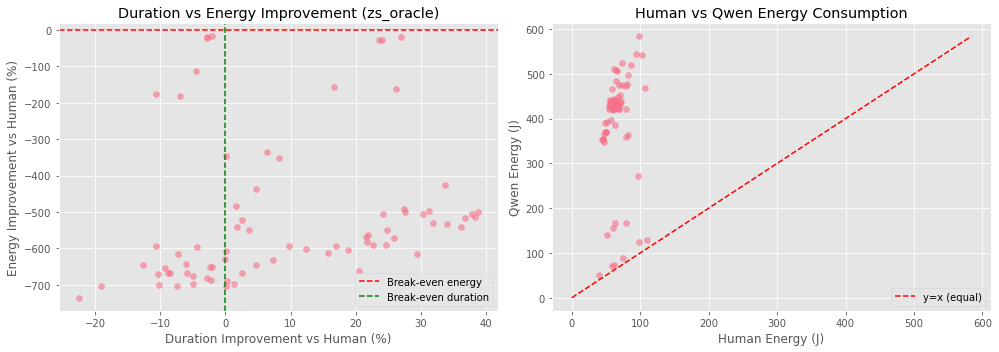


📈 Correlation (duration vs energy improvement): 0.196


In [11]:
# =============================================================================
# CELL 9: Duration vs Energy Analysis - Understanding the Root Cause
# =============================================================================

print("="*70)
print("🔍 DURATION vs ENERGY ANALYSIS")
print("="*70)

# Check if the problem is duration or energy efficiency
config = 'zs_oracle'

mask = (
    df['base_duration_seconds_mean'].notna() & 
    df['human_head_duration_seconds_mean'].notna() & 
    df[f'qwen_{config}_duration_seconds_mean'].notna()
)

analysis = df[mask][['instance_id', 
                      'base_duration_seconds_mean', 'human_head_duration_seconds_mean', f'qwen_{config}_duration_seconds_mean',
                      'base_total_energy_joules_mean', 'human_head_total_energy_joules_mean', f'qwen_{config}_total_energy_joules_mean'
                     ]].copy()

analysis.columns = ['instance_id', 'base_dur', 'human_dur', 'qwen_dur', 'base_energy', 'human_energy', 'qwen_energy']

# Calculate improvements for both metrics
analysis['dur_qwen_vs_human_pct'] = (analysis['human_dur'] - analysis['qwen_dur']) / analysis['human_dur'] * 100
analysis['energy_qwen_vs_human_pct'] = (analysis['human_energy'] - analysis['qwen_energy']) / analysis['human_energy'] * 100

# Calculate power (energy / duration)
analysis['base_power'] = analysis['base_energy'] / analysis['base_dur']
analysis['human_power'] = analysis['human_energy'] / analysis['human_dur']
analysis['qwen_power'] = analysis['qwen_energy'] / analysis['qwen_dur']

print(f"📋 Config: {config} ({len(analysis)} instances)\n")

print("📊 DURATION COMPARISON (seconds):")
print(f"   Human avg duration:  {analysis['human_dur'].mean():.2f}s")
print(f"   Qwen avg duration:   {analysis['qwen_dur'].mean():.2f}s")
print(f"   Qwen vs Human:       {analysis['dur_qwen_vs_human_pct'].mean():.2f}% (positive = Qwen faster)")

print("\n📊 ENERGY COMPARISON (Joules):")
print(f"   Human avg energy:    {analysis['human_energy'].mean():.2f}J")
print(f"   Qwen avg energy:     {analysis['qwen_energy'].mean():.2f}J")
print(f"   Qwen vs Human:       {analysis['energy_qwen_vs_human_pct'].mean():.2f}% (positive = Qwen less energy)")

print("\n📊 POWER COMPARISON (Watts = J/s):")
print(f"   Human avg power:     {analysis['human_power'].mean():.2f}W")
print(f"   Qwen avg power:      {analysis['qwen_power'].mean():.2f}W")
print(f"   Ratio Qwen/Human:    {(analysis['qwen_power'] / analysis['human_power']).mean():.2f}x")

# Scatter plot: Duration improvement vs Energy improvement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Duration vs Energy improvement
ax1 = axes[0]
ax1.scatter(analysis['dur_qwen_vs_human_pct'], analysis['energy_qwen_vs_human_pct'], alpha=0.6)
ax1.axhline(y=0, color='red', linestyle='--', label='Break-even energy')
ax1.axvline(x=0, color='green', linestyle='--', label='Break-even duration')
ax1.set_xlabel('Duration Improvement vs Human (%)')
ax1.set_ylabel('Energy Improvement vs Human (%)')
ax1.set_title(f'Duration vs Energy Improvement ({config})')
ax1.legend()

# Plot 2: Actual values comparison
ax2 = axes[1]
ax2.scatter(analysis['human_energy'], analysis['qwen_energy'], alpha=0.6)
max_val = max(analysis['human_energy'].max(), analysis['qwen_energy'].max())
ax2.plot([0, max_val], [0, max_val], 'r--', label='y=x (equal)')
ax2.set_xlabel('Human Energy (J)')
ax2.set_ylabel('Qwen Energy (J)')
ax2.set_title('Human vs Qwen Energy Consumption')
ax2.legend()

plt.tight_layout()
plt.show()

# Check correlation
corr = analysis['dur_qwen_vs_human_pct'].corr(analysis['energy_qwen_vs_human_pct'])
print(f"\n📈 Correlation (duration vs energy improvement): {corr:.3f}")

In [12]:
# =============================================================================
# CELL 9: Systematic Per-Instance Per-Metric Analysis
# =============================================================================

print("="*70)
print("🔍 SYSTEMATIC ANALYSIS: Per Instance, Per Metric")
print("="*70)

# Configurazione da analizzare (poi faremo per tutte)
config = 'zs_oracle'

# Metriche da confrontare
METRICS_TO_COMPARE = [
    'duration_seconds_mean',
    'total_energy_joules_mean', 
    'cpu_energy_joules_mean',
    'gpu_energy_joules_mean',
    'carbon_grams_mean',
    'power_watts_mean'
]

# Filter instances with all three measurements (base, human, qwen)
mask = (
    df['base_duration_seconds_mean'].notna() & 
    df['human_head_duration_seconds_mean'].notna() & 
    df[f'qwen_{config}_duration_seconds_mean'].notna()
)

subset = df[mask].copy()
print(f"📋 Config: {config}")
print(f"📋 Instances with complete data: {len(subset)}")

# Build detailed comparison table
rows = []
for _, row in subset.iterrows():
    instance_id = row['instance_id']
    
    for metric in METRICS_TO_COMPARE:
        base_val = row[f'base_{metric}']
        human_val = row[f'human_head_{metric}']
        qwen_val = row[f'qwen_{config}_{metric}']
        
        # Skip if any value is missing or zero
        if pd.isna(base_val) or pd.isna(human_val) or pd.isna(qwen_val):
            continue
        if base_val == 0 or human_val == 0:
            continue
        
        # Calculate percentages (positive = improvement/reduction)
        human_vs_base_pct = (base_val - human_val) / base_val * 100
        qwen_vs_base_pct = (base_val - qwen_val) / base_val * 100
        qwen_vs_human_pct = (human_val - qwen_val) / human_val * 100
        
        # Determine rankings (1=best/lowest, 3=worst/highest)
        values = {'base': base_val, 'human': human_val, 'qwen': qwen_val}
        sorted_keys = sorted(values.keys(), key=lambda k: values[k])
        rankings = {k: sorted_keys.index(k) + 1 for k in values}
        
        rows.append({
            'instance_id': instance_id,
            'metric': metric.replace('_mean', ''),
            'base': base_val,
            'human': human_val,
            'qwen': qwen_val,
            'human_vs_base_%': human_vs_base_pct,
            'qwen_vs_base_%': qwen_vs_base_pct,
            'qwen_vs_human_%': qwen_vs_human_pct,
            'rank_base': rankings['base'],
            'rank_human': rankings['human'],
            'rank_qwen': rankings['qwen'],
            'qwen_best': rankings['qwen'] == 1,
            'qwen_worst': rankings['qwen'] == 3,
            'human_best': rankings['human'] == 1,
        })

detail_df = pd.DataFrame(rows)

print(f"📋 Total comparisons: {len(detail_df)} ({len(subset)} instances × {len(METRICS_TO_COMPARE)} metrics)")

# Summary per metric
print("\n" + "="*70)
print("📊 SUMMARY BY METRIC")
print("="*70)

metric_summary = detail_df.groupby('metric').agg({
    'base': 'mean',
    'human': 'mean', 
    'qwen': 'mean',
    'human_vs_base_%': 'mean',
    'qwen_vs_base_%': 'mean',
    'qwen_vs_human_%': 'mean',
    'qwen_best': 'sum',
    'qwen_worst': 'sum',
    'human_best': 'sum',
    'instance_id': 'count'
}).rename(columns={'instance_id': 'n_instances'})

# Add percentage columns
metric_summary['qwen_best_%'] = metric_summary['qwen_best'] / metric_summary['n_instances'] * 100
metric_summary['qwen_worst_%'] = metric_summary['qwen_worst'] / metric_summary['n_instances'] * 100
metric_summary['human_best_%'] = metric_summary['human_best'] / metric_summary['n_instances'] * 100

print("\n📋 Average values per metric:")
print(metric_summary[['base', 'human', 'qwen']].round(2).to_string())

print("\n📋 Win rates (% of instances where each is BEST = lowest value):")
print(metric_summary[['n_instances', 'human_best_%', 'qwen_best_%', 'qwen_worst_%']].round(1).to_string())

print("\n📋 Average improvement percentages (positive = reduction = better):")
print(metric_summary[['human_vs_base_%', 'qwen_vs_base_%', 'qwen_vs_human_%']].round(2).to_string())

🔍 SYSTEMATIC ANALYSIS: Per Instance, Per Metric
📋 Config: zs_oracle
📋 Instances with complete data: 74
📋 Total comparisons: 444 (74 instances × 6 metrics)

📊 SUMMARY BY METRIC

📋 Average values per metric:
                      base  human    qwen
metric                                   
carbon_grams          0.00   0.00    0.03
cpu_energy_joules    41.28  40.61   61.01
duration_seconds      1.67   1.62    1.41
gpu_energy_joules    26.22  25.37  329.83
power_watts          41.78  41.73  277.50
total_energy_joules  67.50  65.98  390.84

📋 Win rates (% of instances where each is BEST = lowest value):
                     n_instances  human_best_%  qwen_best_%  qwen_worst_%
metric                                                                   
carbon_grams                  74          52.7          0.0         100.0
cpu_energy_joules             74          41.9          4.1          91.9
duration_seconds              74          23.0         56.8          27.0
gpu_energy_joules      